# **AI-DRIVEN ASTEROID CLASSIFICATION**
## BIG DATA ANALYTICS | PROJECT SCOPE: SPACE / DEFENCE  
## DATA SOURCE: NASA NEO (NEAR-EARTH OBJECT) https://www.kaggle.com/datasets/sameepvani/nasa-nearest-earth-objects
### AUTHORS: FABRIZIO M. CRIMI 593588 | MICHELE FALCONETTI 596924 | MICHELE STORELLI 598652

---



# **Loading libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# **Data Import**

In [2]:
# Load the dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/neo.csv')

Mounted at /content/drive


# **Data Visualization and Cleaning**

**Checking Missing Values and Duplicates**

In [3]:
# Check for missing values
print(f"Number of NULL values:\n{df.isnull().sum()}")

Number of NULL values:
id                    0
name                  0
absolute_magnitude    0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
hazardous             0
dtype: int64


In [4]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


**Visualization**

In [5]:
# Show the first rows of the dataset
df.head(8)

,id,name,absolute_magnitude,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,hazardous
0,2162635,162635 (2000 SS164),16.73,1.198271,2.679415,13569.24922,54839744.08,Earth,False,False
1,2277475,277475 (2005 WK4),20.00,0.265800,0.594347,73588.72666,61438126.52,Earth,False,True
2,2512244,512244 (2015 YE18),17.83,0.722030,1.614507,114258.69210,49798724.94,Earth,False,False
3,3596030,(2012 BV13),22.20,0.096506,0.215794,24764.30314,25434972.72,Earth,False,False
4,3667127,(2014 GE35),20.09,0.255009,0.570217,42737.73376,46275567.00,Earth,False,True
5,54138696,(2021 GY23),24.32,0.036354,0.081291,34297.58778,40585691.23,Earth,False,False
6,54189957,(2021 PY40),20.95,0.171615,0.383743,27529.47231,29069121.42,Earth,False,False
7,54230078,(2021 XD6),28.49,0.005328,0.011914,57544.47008,55115019.26,Earth,False,False


In [ ]:
# Change the data type of the variable 'id'
df['id'] = df['id'].astype('object')

# Check data types and basic statistics
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  object 
 1   name                90836 non-null  object 
 2   absolute_magnitude  90836 non-null  float64
 3   est_diameter_min    90836 non-null  float64
 4   est_diameter_max    90836 non-null  float64
 5   relative_velocity   90836 non-null  float64
 6   miss_distance       90836 non-null  float64
 7   orbiting_body       90836 non-null  object 
 8   sentry_object       90836 non-null  bool   
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), object(3)
memory usage: 5.7+ MB


In [6]:
# Visualize the main features' statistics
df.describe()

,id,absolute_magnitude,est_diameter_min,est_diameter_max,relative_velocity,miss_distance
count,9.083600e+04,90836.000000,90836.000000,90836.000000,90836.000000,9.083600e+04
mean,1.438288e+07,23.527103,0.127432,0.284947,48066.918918,3.706655e+07
std,2.087202e+07,2.894086,0.298511,0.667491,25293.296961,2.235204e+07
min,2.000433e+06,9.230000,0.000609,0.001362,203.346432,6.745533e+03
25%,3.448110e+06,21.340000,0.019256,0.043057,28619.020648,1.721082e+07
50%,3.748362e+06,23.700000,0.048368,0.108153,44190.117890,3.784658e+07
75%,3.884023e+06,25.700000,0.143402,0.320656,62923.604635,5.654900e+07
max,5.427591e+07,33.200000,37.892650,84.730541,236990.128100,7.479865e+07


**Aggregated Asteroid Distribution**

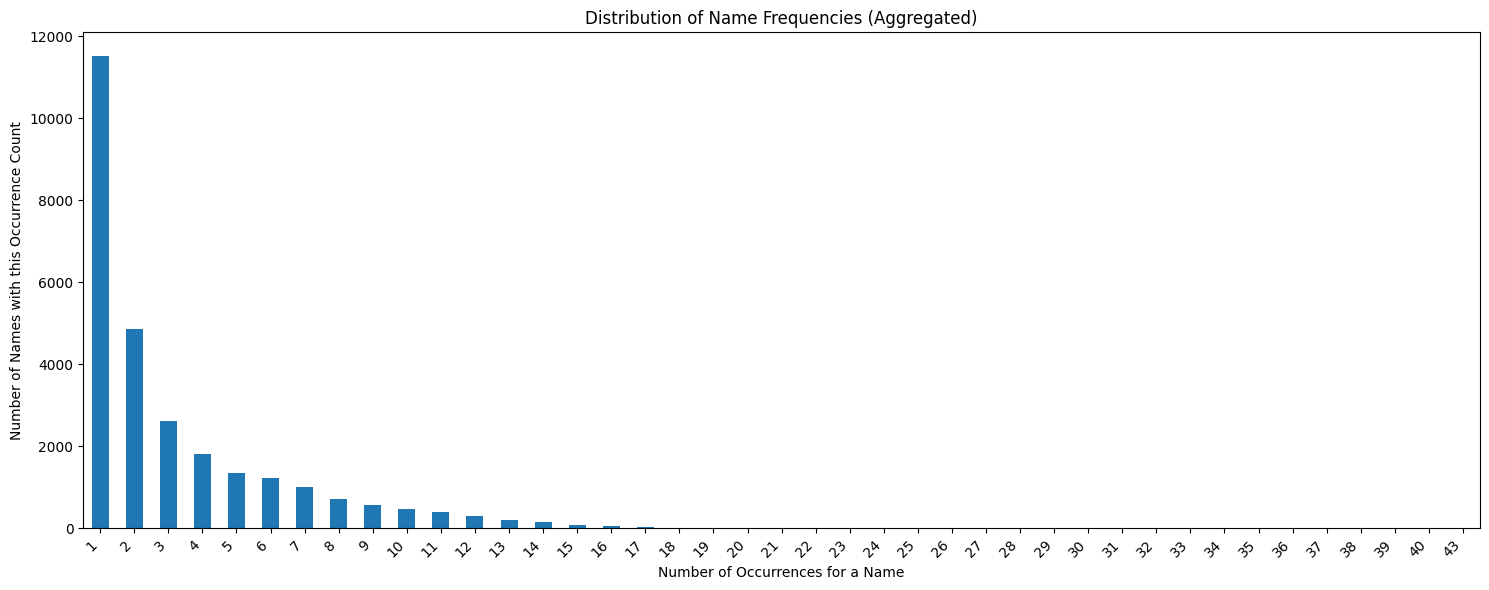

In [7]:
# Calculate the frequency of each asteroid ('name')
name_counts = df['name'].value_counts()

# Calculate the frequency of these counts (how many names appear X times)
frequency_of_counts = name_counts.value_counts().sort_index()

# Create a bar plot for the frequency distribution of frequencies
plt.figure(figsize=(15, 6))
frequency_of_counts.plot(kind='bar')
plt.title('Distribution of Name Frequencies (Aggregated)')
plt.xlabel('Number of Occurrences for a Name')
plt.ylabel('Number of Names with this Occurrence Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Drop Non-Predictive Metadata**

In [8]:
# Drop useless features
df1 = df.drop(columns=['id', 'name'])

# **Exploratory Data Analysis**

**Variance Check for Numerical Features**

In [9]:
# Select only numerical columns
num_cols = df1.select_dtypes(include=['number']).columns

print('Variance of numerical columns:')
print(df1[num_cols].var())

# Identify numerical columns with zero variance
zero_variance_num_cols = num_cols[df1[num_cols].var() == 0]

if not zero_variance_num_cols.empty:
    print('\nNumerical column(s) with zero variance (constants):')
    print(zero_variance_num_cols.tolist())
else:
    print('\nNo numerical columns with zero variance.')

Variance of numerical columns:
absolute_magnitude    8.375731e+00
est_diameter_min      8.910896e-02
est_diameter_max      4.455448e-01
relative_velocity     6.397509e+08
miss_distance         4.996137e+14
dtype: float64

No numerical columns with zero variance.


**Variance Check for Categorical / Boolean Features**


Number of unique values for categorical/boolean columns:
- orbiting_body: 1 unique values
- sentry_object: 1 unique values
- hazardous: 2 unique values

Categorical / boolean column(s) with a single unique value (constants):
- orbiting_body: Earth (constant value)
- sentry_object: False (constant value)




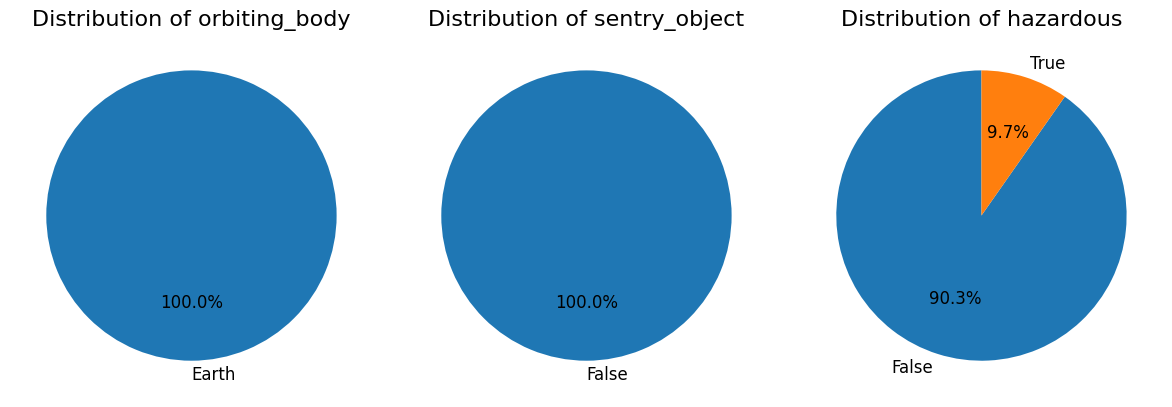



Unique values and their counts for specified columns:

--- Column: orbiting_body ---
orbiting_body
Earth    90836
Name: count, dtype: int64

--- Column: sentry_object ---
sentry_object
False    90836
Name: count, dtype: int64

--- Column: hazardous ---
hazardous
False    81996
True      8840
Name: count, dtype: int64


In [34]:
# Select non-numerical columns
cat_bool_cols = df1.select_dtypes(include=['object', 'bool']).columns

# Identify and inspect unique value counts for categorical and boolean features
print('\nNumber of unique values for categorical/boolean columns:')
for col in cat_bool_cols:
    unique_count = df1[col].nunique()
    print(f'- {col}: {unique_count} unique values')

# Identify categorical/boolean columns with only one unique value (constants)
single_unique_value_cols = [col for col in cat_bool_cols if df1[col].nunique() == 1]

if not single_unique_value_cols:
    print('\nNo categorical / boolean columns with a single unique value.')
else:
    print('\nCategorical / boolean column(s) with a single unique value (constants):')
    for col in single_unique_value_cols:
        print(f'- {col}: {df1[col].iloc[0]} (constant value)')

print("\n")

# Define the columns to analyze
string_columns = ['orbiting_body', 'sentry_object', 'hazardous']

# Create a figure with subplots
fig, axes = plt.subplots(1, len(string_columns), figsize=(4 * len(string_columns), 4))

# Iterate through each column and create a pie chart in a subplot
for i, col in enumerate(string_columns):
    # Calculate value counts
    value_counts = df1[col].value_counts()

    # Create a pie chart in the current subplot
    axes[i].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
    axes[i].set_title(f'Distribution of {col}', fontsize=16)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n")

# Count the number of different values in categorical features
print('Unique values and their counts for specified columns:')
for col in string_columns:
    print(f'\n--- Column: {col} ---')
    print(df1[col].value_counts())

**Drop Zero Variance Features**

In [10]:
# Dropping features with a constant value
df2 = df1.drop(columns=['orbiting_body', 'sentry_object'])

**Encoding the Target Feature**

In [11]:
# Encoding the variable 'hazardous'
df2['hazardous'] = df2['hazardous'].astype(int)

**Correlation Matrix**

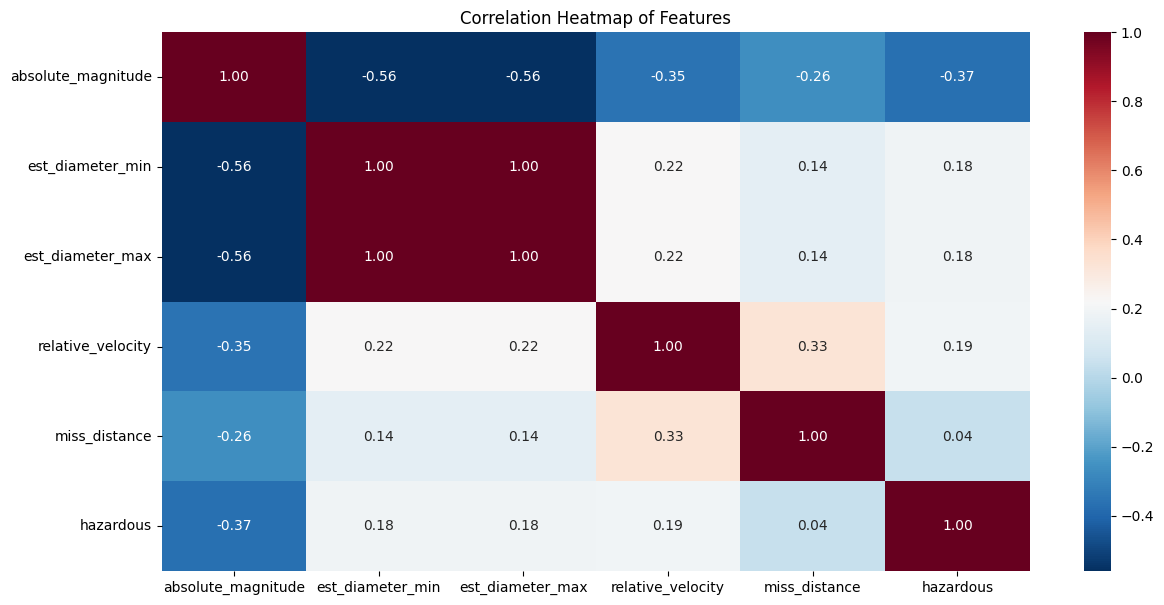

In [12]:
# Calculate the correlation matrix
correlation_matrix = df2.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(14, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

# **Standardization**

**Z-Score Normalization**

In [13]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df2.drop(columns=['hazardous'])
y = df2['hazardous']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame with scaled features
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Add the 'hazardous' target variable back to the scaled DataFrame
df_scaled['hazardous'] = y.values

print("Dataset after Z-Score Normalization:")
df_scaled.head()

Dataset after Z-Score Normalization:


,absolute_magnitude,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,hazardous
0,-2.348632,3.587284,3.587284,-1.363913,0.795153,0
1,-1.218735,0.463529,0.463529,1.009040,1.090357,1
2,-1.968544,1.991887,1.991887,2.616983,0.569624,0
3,-0.458560,-0.103601,-0.103601,-0.921301,-0.520384,0
4,-1.187637,0.427378,0.427378,-0.210697,0.412001,1


# **Splitting Dataset**

In [14]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y) from the scaled DataFrame
X = df_scaled.drop(columns=['hazardous'])
y = df_scaled['hazardous']

# Split data into training (70%) and temporary (30%) sets
# Stratify ensures the ratio of 'hazardous' is preserved across splits
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split temporary data into validation (15%) and test (15%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 63585 samples
Validation set size: 13625 samples
Test set size: 13626 samples


# **Baseline Model: Logistic Regression**

### **Model Definition**

In [ ]:
def sigmoid(z):

    return 1.0 / (1.0 + np.exp(-z))


def compute_cost_logistic(X, y, w, b):

    m, n = X.shape
    cost = 0.0
    epsilon = 1e-15

    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost += -y[i] * np.log(f_wb_i + epsilon) - (1 - y[i]) * np.log(1 - f_wb_i + epsilon)

    cost = cost / m
    return cost


def compute_gradient_logistic(X, y, w, b):

    m, n = X.shape
    dj_dw = np.zeros_like(w)
    dj_db = 0.0

    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        err_i = f_wb_i - y[i]

        for j in range(n):
            dj_dw[j] += err_i * X[i, j]

        dj_db += err_i

    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db


def gradient_descent_logistic(X, y, X_v, y_v, w_in, b_in, alpha, num_iters, verbose=True):

    w = w_in.copy()
    b = float(b_in)

    J_history = []
    J_val_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_logistic(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        cost = compute_cost_logistic(X, y, w, b)
        cost_val = compute_cost_logistic(X_v, y_v, w, b)
        J_history.append(cost)
        J_val_history.append(cost_val)
        if verbose and (i % 100 == 0 or i == num_iters - 1):
            print(f"Iteration {i:4d} | Cost: {cost:.6f} | Val Cost: {cost_val:.6f}")

    return w, b, J_history, J_val_history


def predict_proba(X, w, b):

    return sigmoid(np.dot(X, w) + b)


def predict(X, w, b, threshold=0.5):

    probs = predict_proba(X, w, b)
    return (probs >= threshold).astype(int)

### **Model implementation**

In [ ]:
# Initialize parameters
n = 5
w_init = np.zeros(n)
b_init = 0.0
alpha = 0.1       # Learning Rate
num_iters = 1000  # Number of iterations of gradient descent

# Configuration
X = X_train.values
y = y_train.values
X_v = X_val.values
y_v = y_val.values

# Train logistic regression with gradient descent
w_trained, b_trained, J_history, J_val_history = gradient_descent_logistic(
    X, y, X_v, y_v, w_init, b_init, alpha, num_iters, verbose=True
)

print("\nTrained parameters:")
print("w:", w_trained)
print("b:", b_trained)

Iteration    0 | Cost: 0.675169 | Val Cost: 0.675045
Iteration  100 | Cost: 0.293318 | Val Cost: 0.291470
Iteration  200 | Cost: 0.262514 | Val Cost: 0.260970
Iteration  300 | Cost: 0.251566 | Val Cost: 0.249996
Iteration  400 | Cost: 0.245411 | Val Cost: 0.243906
Iteration  500 | Cost: 0.241292 | Val Cost: 0.239885
Iteration  600 | Cost: 0.238307 | Val Cost: 0.237008
Iteration  700 | Cost: 0.236041 | Val Cost: 0.234846
Iteration  800 | Cost: 0.234263 | Val Cost: 0.233167
Iteration  900 | Cost: 0.232834 | Val Cost: 0.231830
Iteration  999 | Cost: 0.231674 | Val Cost: 0.230754

Trained parameters:
w: [-1.8572668  -0.29827788 -0.29827788  0.21628819 -0.31364121]
b: -2.9854745065395063


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = predict(X_val.values, w_trained, b_trained)

# Evaluation Metrics
print(confusion_matrix(y_val, y_pred))
print("\n")
print(classification_report(y_val, y_pred))

[[12268    31]
 [ 1308    18]]


              precision    recall  f1-score   support

           0       0.90      1.00      0.95     12299
           1       0.37      0.01      0.03      1326

    accuracy                           0.90     13625
   macro avg       0.64      0.51      0.49     13625
weighted avg       0.85      0.90      0.86     13625



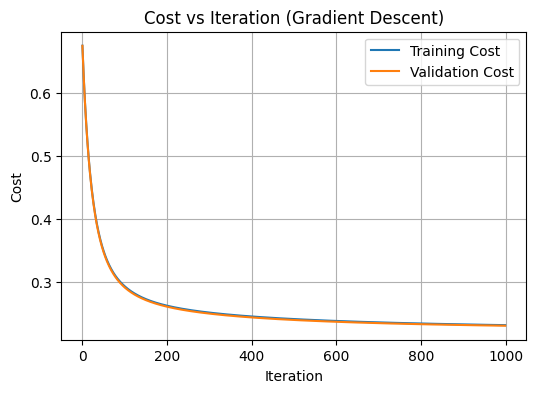

In [ ]:
# Visualization
plt.figure(figsize=(6, 4))
plt.plot(J_history, label='Training Cost')
plt.plot(J_val_history, label='Validation Cost')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration (Gradient Descent)")
plt.legend()
plt.grid(True)
plt.show()

### **Logistic Regression using sklearn (with Class Weighting)**

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

# Initialize the model
log_reg_model = LogisticRegression(random_state=42, class_weight='balanced')

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred = log_reg_model.predict(X_val)

# Evaluation Metrics
print(confusion_matrix(y_val, y_pred))
print("\n")
print(classification_report(y_val, y_pred))

[[9504 2795]
 [  92 1234]]


              precision    recall  f1-score   support

           0       0.99      0.77      0.87     12299
           1       0.31      0.93      0.46      1326

    accuracy                           0.79     13625
   macro avg       0.65      0.85      0.66     13625
weighted avg       0.92      0.79      0.83     13625



In [16]:
from sklearn.metrics import log_loss

# Get predicted probabilities for the training set
y_train_pred_proba = log_reg_model.predict_proba(X_train)[:, 1]

# Calculate the log loss (binary cross-entropy)
log_loss_train = log_loss(y_train, y_train_pred_proba)

# Get predicted probabilities for the validation
y_val_pred_proba = log_reg_model.predict_proba(X_val)[:, 1]

# Calculate the log loss (binary cross-entropy)
log_loss_val = log_loss(y_val, y_val_pred_proba)

print(f"Training Loss (Binary Cross-Entropy): {log_loss_train:.6f}")
print(f"Validation Loss (Binary Cross-Entropy): {log_loss_val:.6f}")

Training Loss (Binary Cross-Entropy): 0.451076
Validation Loss (Binary Cross-Entropy): 0.446351


## **Testing**

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, matthews_corrcoef, cohen_kappa_score

# Generate predictions
y_test_p = log_reg_model.predict(X_test)

# Calculation of indicies (Accuracy, MCC and Kappa)
acc_global = accuracy_score(y_test, y_test_p)
mcc_global = matthews_corrcoef(y_test, y_test_p)
kappa_global = cohen_kappa_score(y_test, y_test_p)

# Printing results
print("Global Performance on full Test set\n")
print(f"Overall Accuracy: {acc_global:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc_global:.4f}")
print(f"Cohen's Kappa: {kappa_global:.4f}\n")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_p, target_names=['Safe (0)', 'Hazardous (1)']))

# Quick interpretation
if mcc_global < 0.3:
    print("\n[NOTE]: The MCC is low (< 0.3). The model might be struggling "
          "to distinguish between classes, possibly due to imbalance.")
elif mcc_global > 0.6:
    print("\n[NOTE]: The MCC is strong (> 0.6). The model shows good "
          "predictive power for both classes.")

Global Performance on full Test set

Overall Accuracy: 0.7833
Matthews Correlation Coefficient (MCC): 0.4523
Cohen's Kappa: 0.3620


Detailed Classification Report:
               precision    recall  f1-score   support

     Safe (0)       0.99      0.77      0.86     12300
Hazardous (1)       0.30      0.93      0.46      1326

     accuracy                           0.78     13626
    macro avg       0.65      0.85      0.66     13626
 weighted avg       0.92      0.78      0.82     13626



Logistic Regression Model (Real)
Sample Size (N): 13626

Accuracy Score: 78.33%
Matthews Correlation Coefficient (MCC): 0.452
Cohen's Kappa: 0.362

Classification Report:
               precision    recall  f1-score   support

     Safe (0)       0.99      0.77      0.86     12300
Hazardous (1)       0.30      0.93      0.46      1326

     accuracy                           0.78     13626
    macro avg       0.65      0.85      0.66     13626
 weighted avg       0.92      0.78      0.82     13626



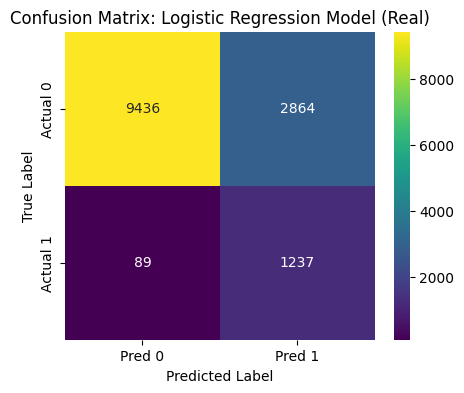



Random Model: Fifty-Fifty (50% Hazardous)
Sample Size (N): 13626

Accuracy Score: 49.99%
Matthews Correlation Coefficient (MCC): 0.008
Cohen's Kappa: 0.005

Classification Report:
               precision    recall  f1-score   support

     Safe (0)       0.91      0.50      0.64     12300
Hazardous (1)       0.10      0.52      0.17      1326

     accuracy                           0.50     13626
    macro avg       0.50      0.51      0.40     13626
 weighted avg       0.83      0.50      0.60     13626



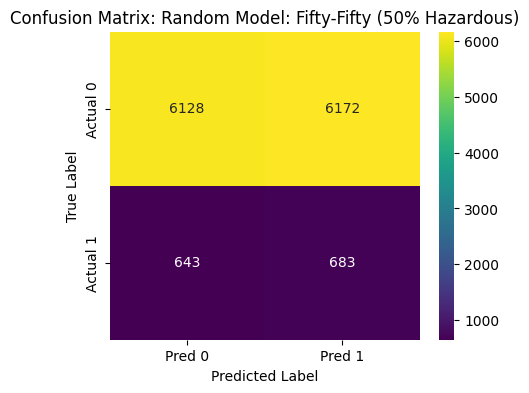



Baseline: 95% Pred Hazardous (Majority 1)
Sample Size (N): 13626

Accuracy Score: 13.91%
Matthews Correlation Coefficient (MCC): 0.004
Cohen's Kappa: 0.001

Classification Report:
               precision    recall  f1-score   support

     Safe (0)       0.91      0.05      0.10     12300
Hazardous (1)       0.10      0.95      0.18      1326

     accuracy                           0.14     13626
    macro avg       0.50      0.50      0.14     13626
 weighted avg       0.83      0.14      0.11     13626



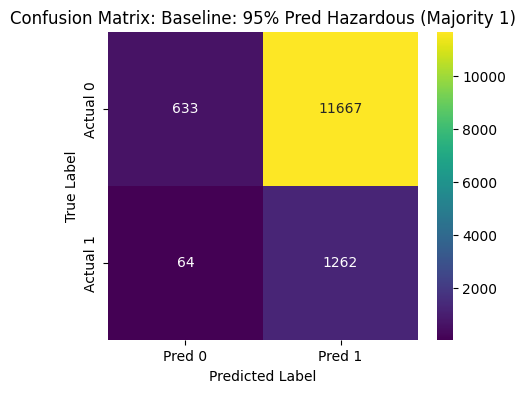



Baseline: 95% Pred Safe (Majority 0)
Sample Size (N): 13626

Accuracy Score: 86.04%
Matthews Correlation Coefficient (MCC): -0.008
Cohen's Kappa: -0.007

Classification Report:
               precision    recall  f1-score   support

     Safe (0)       0.90      0.95      0.92     12300
Hazardous (1)       0.09      0.05      0.06      1326

     accuracy                           0.86     13626
    macro avg       0.49      0.50      0.49     13626
 weighted avg       0.82      0.86      0.84     13626



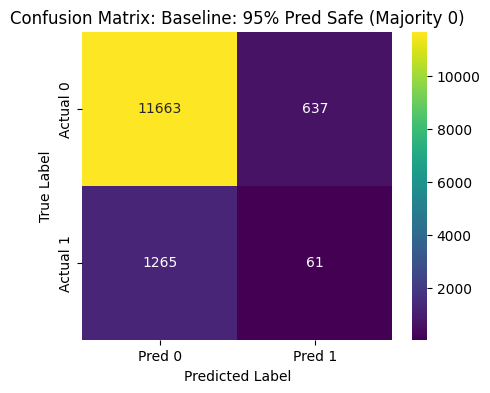

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, matthews_corrcoef, cohen_kappa_score

# Generate predictions
y_test_pred = log_reg_model.predict(X_test)

# Consolidate results into a DataFrame for structured filtering
results_df = pd.DataFrame({
    'ground_truth': y_test,
    'prediction': y_test_pred
})

# Utility Functions

def create_scenario(y_true_series, target_ratio, label_to_focus):
    """
    Generates a 'fake' (baseline) prediction vector based solely on probability,
    without considering what the actual model predicted
    """
    n_total = len(y_true_series)

    # Probability: if label_to_focus is 0, set target_ratio to 0 and the rest to 1
    if label_to_focus == 0:
        p_dist = [target_ratio, 1 - target_ratio]
    else:
        p_dist = [1 - target_ratio, target_ratio]

    # Generate the "naive" vector
    y_fake_pred = np.random.choice([0, 1], size=n_total, p=p_dist)

    # Return a DataFrame coupling the ground truth with the fake prediction
    return pd.DataFrame({
        'ground_truth': y_true_series.values,
        'prediction': y_fake_pred
    })

def evaluate_phase(df_subset, phase_name):
    """
    Computes evaluation metrics and displays a Confusion Matrix for the subset
    """
    print(f"{phase_name}")
    print(f"Sample Size (N): {len(df_subset)}\n")

    y_true = df_subset['ground_truth']
    y_p = df_subset['prediction']
    mcc = matthews_corrcoef(y_true, y_p)
    kappa = cohen_kappa_score(y_true, y_p)

    # Textual Metrics
    print(f"Accuracy Score: {accuracy_score(y_true, y_p):.2%}")
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.3f}")
    print(f"Cohen's Kappa: {kappa:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_p, labels=[0, 1],
                                target_names=['Safe (0)', 'Hazardous (1)'],
                                zero_division=0))

    # Visual Matrix
    cm = confusion_matrix(y_true, y_p, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f"Confusion Matrix: {phase_name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print("\n")

# Execution

# Phase 0: Real model
evaluate_phase(results_df, "Logistic Regression Model (Real)")

# Phase 1: RAND Baseline (Random predictions based on a 50/50)
phase1_df = create_scenario(y_test, target_ratio=0.50, label_to_focus=1)
evaluate_phase(phase1_df, "Random Model: Fifty-Fifty (50% Hazardous)")

# Phase 2: MAJ1 Baseline (95% randomly predicts Hazardous)
phase2_df = create_scenario(y_test, target_ratio=0.95, label_to_focus=1)
evaluate_phase(phase2_df, "Baseline: 95% Pred Hazardous (Majority 1)")

# Phase 3: MAJ0 Baseline (95% randomly predicts Safe)
phase3_df = create_scenario(y_test, target_ratio=0.95, label_to_focus=0)
evaluate_phase(phase3_df, "Baseline: 95% Pred Safe (Majority 0)")

# **Advanced Model: Artificial Neural Network**

## **NN without Class Weighting**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9012 - loss: 0.3821 - val_accuracy: 0.9027 - val_loss: 0.1982
Epoch 2/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9020 - loss: 0.1980 - val_accuracy: 0.9027 - val_loss: 0.1924
Epoch 3/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9015 - loss: 0.1947 - val_accuracy: 0.9027 - val_loss: 0.1905
Epoch 4/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9026 - loss: 0.1921 - val_accuracy: 0.9027 - val_loss: 0.1886
Epoch 5/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9030 - loss: 0.1897 - val_accuracy: 0.9027 - val_loss: 0.1877
Epoch 6/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9024 - loss: 0.1896 - val_accuracy: 0.9027 - val_loss: 0.1874
Epoch 7/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9037 - loss: 0.1880 - val_accuracy: 0.9027 - val_loss: 0.1872
Epoch 8/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9052 - loss

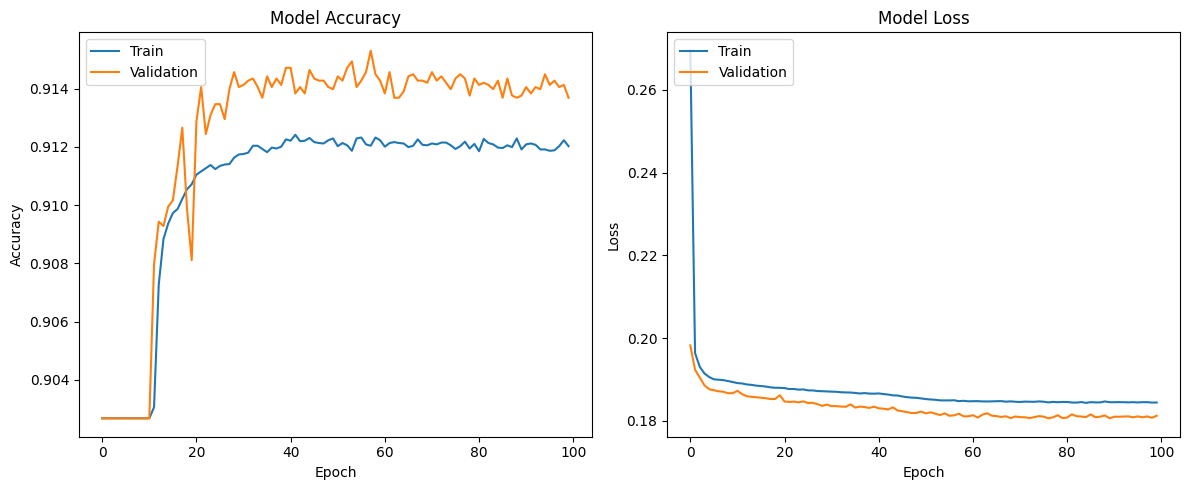

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

# Model Architecture
model = Sequential ([
    Dense(units=5, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(units=3, activation='relu'),
    Dense(units=1, activation='linear')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Model Training
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val, y_val))
model_loss = model.evaluate(X_test, y_test, verbose=1)

# Prediction and Inference
y_logits = model.predict(X_test)
y_probs = tf.nn.sigmoid(y_logits).numpy()
y_test_pred = (y_probs > 0.5).astype(int)

# Evaluation Metrics
print("Results without Class Weighting\n")
print(f"MCC: {matthews_corrcoef(y_test, y_test_pred):.4f}")
print(f"Kappa: {cohen_kappa_score(y_test, y_test_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## **NN with Class Weighting**

### **NN with 1 Hidden Layer**

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1988/1988 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7974 - loss: 0.5168 - val_accuracy: 0.7836 - val_loss: 0.4001
Epoch 2/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7838 - loss: 0.3280 - val_accuracy: 0.7842 - val_loss: 0.3800
Epoch 3/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7832 - loss: 0.3174 - val_accuracy: 0.7933 - val_loss: 0.3490
Epoch 4/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7824 - loss: 0.3159 - val_accuracy: 0.7901 - val_loss: 0.3595
Epoch 5/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7846 - loss: 0.3112 - val_accuracy: 0.7898 - val_loss: 0.3855
Epoch 6/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7898 - loss: 0.3100 - val_accuracy: 0.7911 - val_loss: 0.3736
Epoch 7/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7888 - loss: 0.3102 - val_accuracy: 0.7982 - val_loss: 0.3511
Epoch 8/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7903 - loss: 0.3089 - val

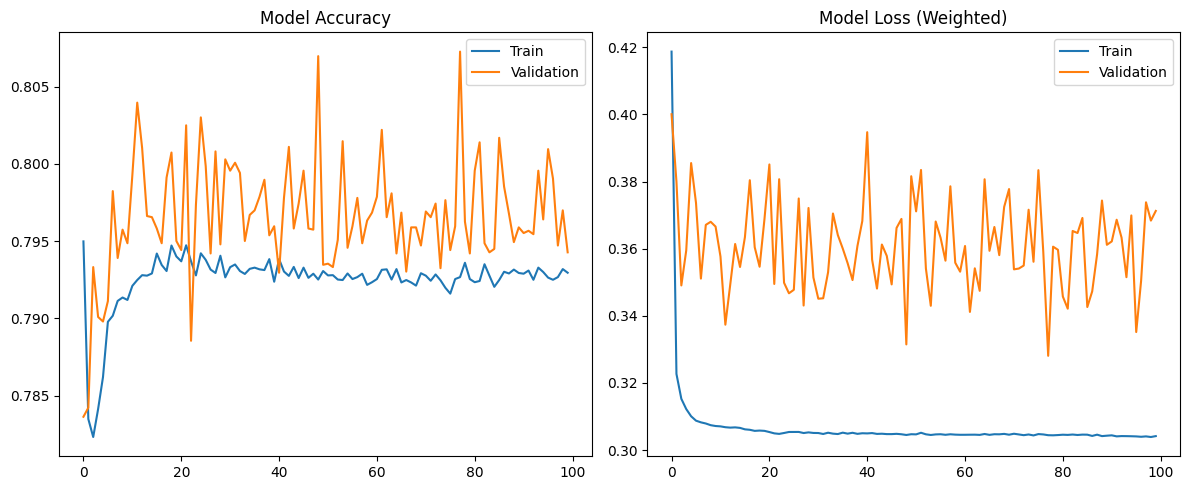

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, cohen_kappa_score

# Class Weight Calculation
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_dict = dict(enumerate(class_weights))

# Model Architecture
model = Sequential ([
    Dense(units=5, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(units=3, activation='relu'),
    Dense(units=1, activation='linear')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Model Training
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=weights_dict,
    verbose=1
)

# Prediction and Inference
y_logits = model.predict(X_test)
y_probs = tf.nn.sigmoid(y_logits).numpy()
y_test_pred = (y_probs > 0.5).astype(int)

# Evaluation Metrics
print("Results with Class Weighting\n")
print(f"MCC: {matthews_corrcoef(y_test, y_test_pred):.4f}")
print(f"Kappa: {cohen_kappa_score(y_test, y_test_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss (Weighted)')
plt.legend()

plt.tight_layout()
plt.show()

### **NN with 2 Hidden Layers**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8036 - loss: 0.3617 - val_accuracy: 0.7837 - val_loss: 0.3952
Epoch 2/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7864 - loss: 0.3162 - val_accuracy: 0.7888 - val_loss: 0.3578
Epoch 3/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7919 - loss: 0.3117 - val_accuracy: 0.7930 - val_loss: 0.3792
Epoch 4/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7932 - loss: 0.3038 - val_accuracy: 0.8085 - val_loss: 0.2955
Epoch 5/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7886 - loss: 0.3102 - val_accuracy: 0.7963 - val_loss: 0.3498
Epoch 6/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7899 - loss: 0.3090 - val_accuracy: 0.7866 - val_loss: 0.3895
Epoch 7/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7887 - loss: 0.3079 - val_accuracy: 0.7954 - val_loss: 0.3056
Epoch 8/100
1988/1988 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7870 - loss: 0

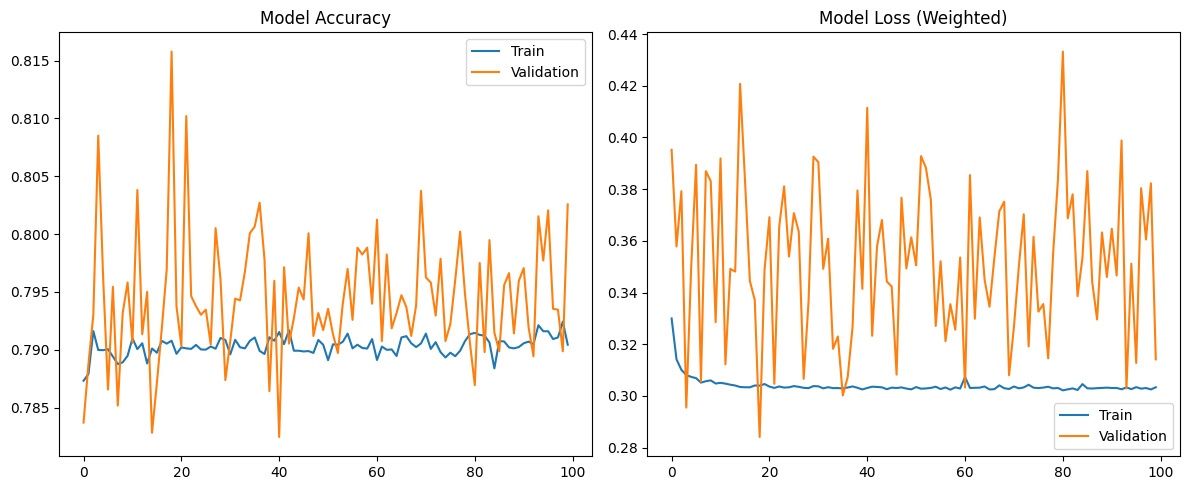

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, cohen_kappa_score

# Class Weight Calculation
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_dict = dict(enumerate(class_weights))

# Model Architecture
model = Sequential ([
    Dense(units=5, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(units=2, activation='relu'),
    Dense(units=4, activation='relu'),
    Dense(units=1, activation='linear')
])

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Model Training
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=weights_dict,
    verbose=1
)

# Prediction and Inference
y_logits = model.predict(X_test)
y_probs = tf.nn.sigmoid(y_logits).numpy()
y_test_pred = (y_probs > 0.5).astype(int)

# Evaluation Metrics
print("Results with Class Weighting\n")
print(f"MCC: {matthews_corrcoef(y_test, y_test_pred):.4f}")
print(f"Kappa: {cohen_kappa_score(y_test, y_test_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss (Weighted)')
plt.legend()

plt.tight_layout()
plt.show()

### **NN with Learning Rate Scheduler**

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


249/249 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9018 - loss: 0.6950 - val_accuracy: 0.9027 - val_loss: 0.6902 - learning_rate: 5.0000e-05
Epoch 2/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9045 - loss: 0.6857 - val_accuracy: 0.9027 - val_loss: 0.6868 - learning_rate: 5.0000e-05
Epoch 3/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9026 - loss: 0.6897 - val_accuracy: 0.9027 - val_loss: 0.6796 - learning_rate: 5.0000e-05
Epoch 4/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9048 - loss: 0.6772 - val_accuracy: 0.9027 - val_loss: 0.6587 - learning_rate: 5.0000e-05
Epoch 5/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9055 - loss: 0.6617 - val_accuracy: 0.9027 - val_loss: 0.6314 - learning_rate: 5.0000e-05
Epoch 6/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9044 - loss: 0.6513 - val_accuracy: 0.9027 - val_loss: 0.6100 - learning_rate: 5.0000e-05
Epoch 7/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.902

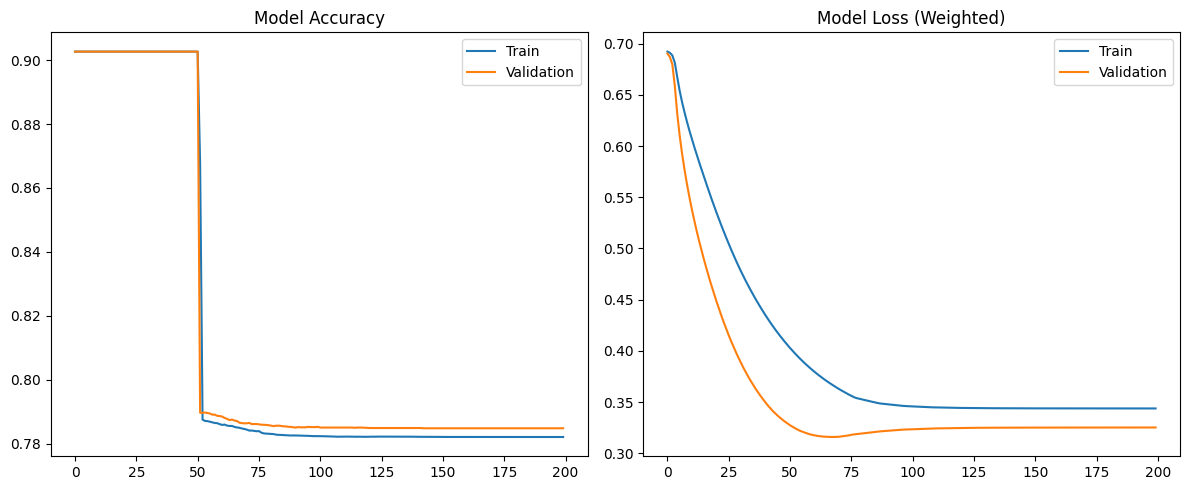

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, cohen_kappa_score

# Learning Rate Scheduler (if val_loss does not improve for 10 epochs, reduce the learning rate by 50%)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5,
                              patience=10,
                              min_lr=1e-7,
                              verbose=1)

# Class Weight Calculation
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_dict = dict(enumerate(class_weights))

# Model Architecture
model = Sequential ([
    Dense(units=5, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(units=3, activation='relu'),
    Dense(units=1, activation='linear')
])

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss=BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Model Training
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=256,
    validation_data=(X_val, y_val),
    class_weight=weights_dict,
    verbose=1,
    callbacks=[reduce_lr]
)

# Prediction and Inference
y_logits = model.predict(X_test)
y_probs = tf.nn.sigmoid(y_logits).numpy()
y_test_pred = (y_probs > 0.5).astype(int)

# Evaluation Metrics
print("Results with Class Weighting and Learning Rate Scheduler\n")
print(f"MCC: {matthews_corrcoef(y_test, y_test_pred):.4f}")
print(f"Kappa: {cohen_kappa_score(y_test, y_test_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss (Weighted)')
plt.legend()

plt.tight_layout()
plt.show()

## **Hyperparameters Optimization**

Class weights: {0: np.float64(0.5539052563722843), 1: np.float64(5.137766645119586)}
Starting Nodes Experiment with Balanced Weights...
Training architecture: (3, None) with balanced weights...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AUC for (3, None): 0.8856
Training architecture: (5, None) with balanced weights...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AUC for (5, None): 0.8883
Training architecture: (8, None) with balanced weights...


...

AUC for (8, 4): 0.8882
Training architecture: (10, 5) with balanced weights...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AUC for (10, 5): 0.8859
Training architecture: (16, 8) with balanced weights...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AUC for (16, 8): 0.8809


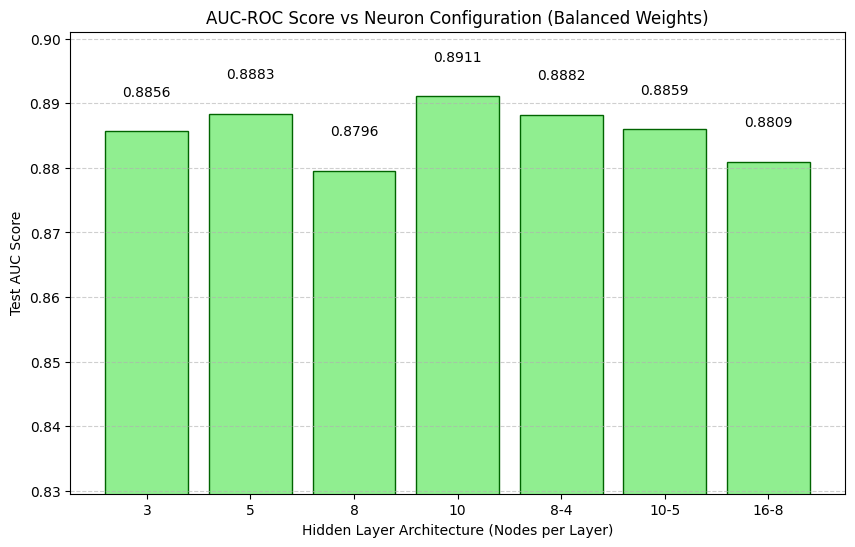

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.utils.class_weight import compute_class_weight

# Nodes and Layers Experiment

# Class wiights for balancing
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(weights)}

print(f"Class weights: {class_weight_dict}")

# Define architectures to test
node_configs = [
    (3, None), (5, None), (8, None), (10, None), (8, 4), (10, 5), (16, 8)
]
config_labels = ["3", "5", "8", "10", "8-4", "10-5", "16-8"]
test_results_auc = []

print("Starting Nodes Experiment with Balanced Weights...")

for config in node_configs:
    model = Sequential()
    model.add(Dense(config[0], activation='relu', input_shape=(X_train.shape[1],)))
    if config[1] is not None:
        model.add(Dense(config[1], activation='relu'))

    # Output Layer
    model.add(Dense(1, activation='linear'))

    # AUC Metric for unbalanced dataset
    model.compile(
        optimizer='adam',
        loss=BinaryCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    # Fit
    print(f"Training architecture: {config} with balanced weights...")
    model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        verbose=0,
        validation_data=(X_val, y_val),
        class_weight=class_weight_dict
    )

    # Evaluation
    results = model.evaluate(X_test, y_test, verbose=0)
    auc_score = results[1]
    test_results_auc.append(auc_score)
    print(f"AUC for {config}: {auc_score:.4f}")

# Plotting the results
plt.figure(figsize=(10, 6))
bars = plt.bar(config_labels, test_results_auc, color='lightgreen', edgecolor='darkgreen')
plt.ylim(min(test_results_auc) - 0.05, max(test_results_auc) + 0.01)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}', ha='center', va='bottom')
plt.title('AUC-ROC Score vs Neuron Configuration (Balanced Weights)')
plt.xlabel('Hidden Layer Architecture (Nodes per Layer)')
plt.ylabel('Test AUC Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()